In [1]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [2]:
def load_data_cblv_only(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    n_de_mutantes = np.load(f'mutation_dataset_10-06_v{v}\\number_of_mutantes.npy')
    n_de_mutantes = np.delete(n_de_mutantes, simulacoes_com_erro)
    sem_mutação = np.where(n_de_mutantes <= 3)
    R_nought2[sem_mutação[0]] = R_nought1[sem_mutação[0]]


    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_reascale))

    masked = np.multiply(trees_cblv, mutation_masks)
    trees_cblv_and_masked = np.column_stack((trees_cblv, masked))

    return trees_cblv, vectorized, rescale_factors

In [3]:
X, y, rescale_factors = load_data_cblv_only(0)

In [4]:
test_size = 1000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [5]:
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [6]:
modelo = tf.keras.models.load_model("modelos\\2000\\modelo.keras")

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 501, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 499, 50)        │           350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 490, 50)        │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 80)         │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 80)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,307 (860.58 KB)

 Trainable params: 73,435 (286.86 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 146,872 (573.72 KB)

In [7]:
pred = modelo.predict(X_test)
pred = scaler.inverse_transform(pred)
pred[:, 2] *= rescale_factors[-test_size:]



32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [8]:
#run it once!
y_test = scaler.inverse_transform(y_test)
y_test[:, 2] *= rescale_factors[-test_size:]

In [9]:
erro_relativo_cblv_only = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R01:", erro_relativo_cblv_only[0])
print("MAPE R02:", erro_relativo_cblv_only[1])
print("MAPE Inf:", erro_relativo_cblv_only[2])

MAPE R01: 0.11655120968866323
MAPE R02: 0.306146594792797
MAPE Inf: 0.0695611896252229


In [10]:
MAPEs_cblv_only = np.abs((pred - y_test) / y_test) * 100
MAPEs_cblv_only = MAPEs_cblv_only[:300]

In [45]:
MAPEs_cblv_only.shape

(300, 3)

---

In [12]:
def load_data_avec_true_mask(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])

    # Corrigindo os parâmetros do R02 para árvores com pouca mutação
    n_de_mutantes = np.load(f'mutation_dataset_10-06_v{v}\\number_of_mutantes.npy')
    n_de_mutantes = np.delete(n_de_mutantes, simulacoes_com_erro)
    sem_mutação = np.where(n_de_mutantes <= 5)
    R_nought2[sem_mutação[0]] = R_nought1[sem_mutação[0]]

    # Corrigindo o R01 para árvores em que a mutação é mais de 95% dos nós
    n_nos = np.count_nonzero(trees_cblv, axis=1)
    proporcao_mutacao = n_de_mutantes / n_nos
    muita_mutacao = np.where(proporcao_mutacao > 0.95)
    R_nought1[muita_mutacao[0]] = R_nought2[muita_mutacao[0]]


    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_reascale))

    masked = np.multiply(trees_cblv, mutation_masks)
    trees_cblv_and_masked = np.column_stack((trees_cblv, masked))

    return trees_cblv_and_masked, vectorized, rescale_factors

In [13]:
X, y, rescale_factors = load_data_avec_true_mask(0)

In [14]:
test_size = 10000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [15]:
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [16]:
modelo = tf.keras.models.load_model("modelos\\9000\\modelo.keras")

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 501, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 499, 50)        │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 490, 50)        │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 80)         │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 80)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,207 (864.09 KB)

 Trainable params: 73,735 (288.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 147,472 (576.07 KB)

In [17]:
pred = modelo.predict(X_test)
pred = scaler.inverse_transform(pred)
pred[:, 2] *= rescale_factors[-test_size:]


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [18]:
#run it once!
y_test = scaler.inverse_transform(y_test)
y_test[:, 2] *= rescale_factors[-test_size:]

In [19]:
erro_relativo_avec_true_mask = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R01:", erro_relativo_avec_true_mask[0])
print("MAPE R02:", erro_relativo_avec_true_mask[1])
print("MAPE Inf:", erro_relativo_avec_true_mask[2])

MAPE R01: 0.10024443822704146
MAPE R02: 0.10964834223096488
MAPE Inf: 0.06787967337777892


In [20]:
MAPEs_cblv_avec_true_mask = np.abs((pred - y_test) / y_test) * 100
MAPEs_cblv_avec_true_mask = MAPEs_cblv_avec_true_mask[:300]

---

In [21]:
modelo = tf.keras.models.load_model("C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\modelos\\c1400\\modelo.keras")

In [22]:
mask_pred = np.load("C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\neural_networks_dot_keras\\04-07\\mask_prediction\\pred_mask_04-07_v0.npy")


X_test_avec_mask = np.column_stack((X_test[:, :1002], mask_pred))
X_test_avec_mask_binary = np.column_stack((X_test[:, :1002], (mask_pred > 0.7).astype(int)))

In [23]:
pred = modelo.predict(X_test_avec_mask_binary)
pred = scaler.inverse_transform(pred)
pred[:, 2] *= rescale_factors[-test_size:]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [44]:
# Run it once!
y_test = scaler.inverse_transform(y_test)
y_test[:, 1] *= rescale_factors[-test_size:]

In [46]:
erro_relativo_avec_pred_mask = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R01:", erro_relativo_avec_pred_mask[0])
print("MAPE R02:", erro_relativo_avec_pred_mask[1])
print("MAPE Inf:", erro_relativo_avec_pred_mask[2])

MAPE R01: 0.2992446253413451
MAPE R02: 0.3660124321501296
MAPE Inf: 0.16964417657413047


In [47]:
MAPEs_cblv_avec_pred_mask = np.abs((pred - y_test) / y_test) * 100
MAPEs_cblv_avec_pred_mask = MAPEs_cblv_avec_pred_mask[:300]

---

In [35]:
with open(f'C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\simulacoes_com_erro.pkl', 'rb') as arquivo:
    simulacoes_com_erro = pickle.load(arquivo)

erros_validos = [i for i in simulacoes_com_erro if 0 <= i < 10000]

# loading parameters
param_train = pd.read_csv('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\tabela_100k_phyloCNN.txt', sep='\t')
#param_test = pd.read_csv('./testset/parameters_BD.txt', sep='\t')

param_train = param_train[:10000]
param_train = param_train.drop(erros_validos, axis=0)
param_test = param_train[-500:]
param_train = param_train[:-500]


n_de_mutantes = np.load('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\number_of_mutantes.npy')
n_de_mutantes = n_de_mutantes[:10000]
n_de_mutantes = np.delete(n_de_mutantes, erros_validos)
n_de_mutantes_test = n_de_mutantes[-500:]
n_de_mutantes_train = n_de_mutantes[:-500]


mask_train = n_de_mutantes_train <= 5
param_train.loc[mask_train, "R_nought_2"] = param_train.loc[mask_train, "R_nought_1"]

mask_test = n_de_mutantes_test <= 5
param_test.loc[mask_test, "R_nought_2"] = param_test.loc[mask_test, "R_nought_1"]

# loading tree encoding
#encoding = pd.read_csv('./Encoded_trees_BD.csv', sep="\t", header=0, index_col=0).values.reshape(-1,1000,18)
#encoding_test = pd.read_csv('./testset/Encoded_trees_BD.csv', sep="\t", header=0, index_col=0).values.reshape(-1,1000,18)

In [36]:
encoding = pd.read_csv('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\split_trees_encoded\\encoded_tree_part_0.csv', sep="\t", header=0, index_col=0).values.reshape(-1,1000,18)
print(encoding.shape)
encoding = np.delete(encoding, erros_validos, axis=0)
encoding_test = encoding[-500:]
encoding = encoding[:-500]

(10000, 1000, 18)


In [37]:
#Reshape parameters (and rescale them) and encodings:

### TRAINING SET: PARAMETER VALUES
# extract rescaling factor (last line of each encoded tree)
param_train['resc_factor'] = encoding[:,-1,-1]

# rescale target values according to scaling factor
# The BD and BDEI simulators use 'infectious time' for the name of this parameter. BDSS simulator use 'infectious period'.
key = 'infectious_period' if 'infectious_period' in param_train else 'infectious_time'
param_train['infectious_period'] = param_train.pop(key) / param_train['resc_factor']

### TESTING SET: PARAMETER VALUES
# extract rescaling factor  (last line of each encoded tree)
param_test['resc_factor'] = encoding_test[:,-1,-1]
# rescale target values
key = 'infectious_period' if 'infectious_period' in param_test else 'infectious_time'
param_test['infectious_period'] = param_test.pop(key) / param_test['resc_factor']

# remove irrelevant columns: rescaling factor
encoding=np.delete(encoding, -1, axis=1)
encoding_test=np.delete(encoding_test, -1, axis=1)

#Choice of the parameters to predict
target_1 = "R_nought_1"
target_2 = "R_nought_2"
target_3 = "infectious_period"

#Add parameters to predict as labels for each simulation
Y = pd.DataFrame(param_train[[target_1, target_2, target_3]])
Y_test = pd.DataFrame(param_test[[target_1, target_2, target_3]])

#Fraction of the training trees to be used as validation and training set
valid_frac = 0.3
train_size_frac = 0.7

In [38]:
#Now insert an additional column with sampling proba for all nodes

samp_proba_list = np.array(param_train['sampling_proba'])
encoding=np.concatenate((encoding,np.repeat(samp_proba_list,999).reshape(-1,999,1)),axis=2)

samp_proba_list_test = np.array(param_test['sampling_proba'])
encoding_test=np.concatenate((encoding_test,np.repeat(samp_proba_list_test,999).reshape(-1,999,1)),axis=2)

In [39]:
# This function takes in the tree encodings for both training and testing datasets
# and processes them to have a uniform shape. It also pads the leaves and nodes 
# of the trees to ensure each tree has a fixed number of 500 leaves and nodes.

def encode_pad_0s_rootage(enc, enc_test):
    # Create an empty list to hold padded training encodings
    enc_pad = []
    
    # Iterate over each tree in the training dataset
    for i in range(enc.shape[0]):
        # Separate the leaves (where column 3 has value 1, which indicates leaves)
        leaves = enc[i][enc[i,:,3] == 1]
        # Sort leaves by their age (assumed to be in column 1)
        leaves = leaves[np.argsort(leaves[:, 1])]
        # Pad the leaves array with 0s until it has a maximum size of 500 leaves
        leaves = np.pad(leaves, [(0, (500 - leaves.shape[0])), (0, 0)], mode='constant')

        # Separate the nodes (where column 3 is greater than 1, indicating internal nodes)
        nodes = enc[i][enc[i,:,3] > 1]
        # Sort nodes by their age (assumed to be in column 1)
        nodes = nodes[np.argsort(nodes[:, 1])]
        # Copy the last node's value to balance the number of leaves and nodes
        nodes = np.append(nodes, nodes[-1].reshape(1, -1), axis=0)
        # Pad the nodes array with 0s to ensure a size of 500 nodes
        nodes = np.pad(nodes, [(0, (500 - nodes.shape[0])), (0, 0)], mode='constant')
        
        # Stack the leaves and nodes arrays together along axis 2 (creating 2 channels)
        enc_pad.append(np.stack((leaves, nodes), axis=2))
    
    # Now process the test dataset (same procedure as above)
    enc_pad_test = []
    for i in range(enc_test.shape[0]):
        # Extract and sort leaves
        leaves = enc_test[i][enc_test[i,:,3] == 1]
        leaves = leaves[np.argsort(leaves[:, 1])]
        # Pad leaves to ensure size of 500
        leaves = np.pad(leaves, [(0, (500 - leaves.shape[0])), (0, 0)], mode='constant')

        # Extract and sort nodes
        nodes = enc_test[i][enc_test[i,:,3] > 1]
        nodes = nodes[np.argsort(nodes[:, 1])]
        # Copy the last node's value to balance the number of leaves and nodes
        nodes = np.append(nodes, nodes[-1].reshape(1, -1), axis=0)
        # Pad nodes to ensure size of 500
        nodes = np.pad(nodes, [(0, (500 - nodes.shape[0])), (0, 0)], mode='constant')
        
        # Stack the leaves and nodes arrays together along axis 2 (creating 2 channels)
        enc_pad_test.append(np.stack((leaves, nodes), axis=2))
    
    # Convert lists to numpy arrays and return the padded training and test data
    return np.array(enc_pad), np.array(enc_pad_test)


#Change encoding to order by root age and pad with 0s
encoding_pad, encoding_pad_test = encode_pad_0s_rootage(encoding, encoding_test)

In [40]:
path = 'C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\phyloCNN-main\\Trained_BDMT\\v0-corrected_mutation'

In [41]:
#load the model
from keras.models import model_from_json
json_file = open(path + '\\Trained_BDMT_01-08_v0.json', 'r')
model = json_file.read()
json_file.close()
estimator = model_from_json(model)
#load weights
estimator.load_weights(path + '\\Trained_BDMT_01-08_v0.weights.h5')
print('model loaded!')



model loaded!


In [42]:
# predict values for the test set
predicted_test = pd.DataFrame(estimator.predict(encoding_pad_test))
predicted_test.columns = Y_test.columns # rename correctly the columns
predicted_test.index = Y_test.index # rename indexes for correspondence

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [43]:


#Target
Y_test_rescaled=pd.DataFrame(Y_test)
Y_test_rescaled['infectious_period'] = Y_test_rescaled['infectious_period']*param_test['resc_factor']
#Y_test_rescaled.to_csv(path + '\\Y_test_rescaled.csv', header=True)

#Predicted
predicted_test['infectious_period'] = predicted_test['infectious_period']*param_test['resc_factor']
#predicted_test.to_csv(path + '\\predicted_test.csv', header=True)

In [44]:
mape_r01_phylo = np.mean(np.abs((Y_test_rescaled["R_nought_1"] - predicted_test["R_nought_1"]) / Y_test_rescaled["R_nought_1"]))
mape_r02_phylo = np.mean(np.abs((Y_test_rescaled["R_nought_2"] - predicted_test["R_nought_2"]) / Y_test_rescaled["R_nought_2"]))
mape_inf_phylo = np.mean(np.abs((Y_test_rescaled["infectious_period"] - predicted_test["infectious_period"]) / Y_test_rescaled["infectious_period"]))

print("MAPE R01:", mape_r01_phylo)
print("MAPE R02:", mape_r02_phylo)
print("MAPE Inf:", mape_inf_phylo)


MAPE R01: 0.11053546348356694
MAPE R02: 0.13783919334474778
MAPE Inf: 0.06142700381863564


In [48]:
mape_phylo = np.abs((Y_test_rescaled - predicted_test) / Y_test_rescaled) * 100

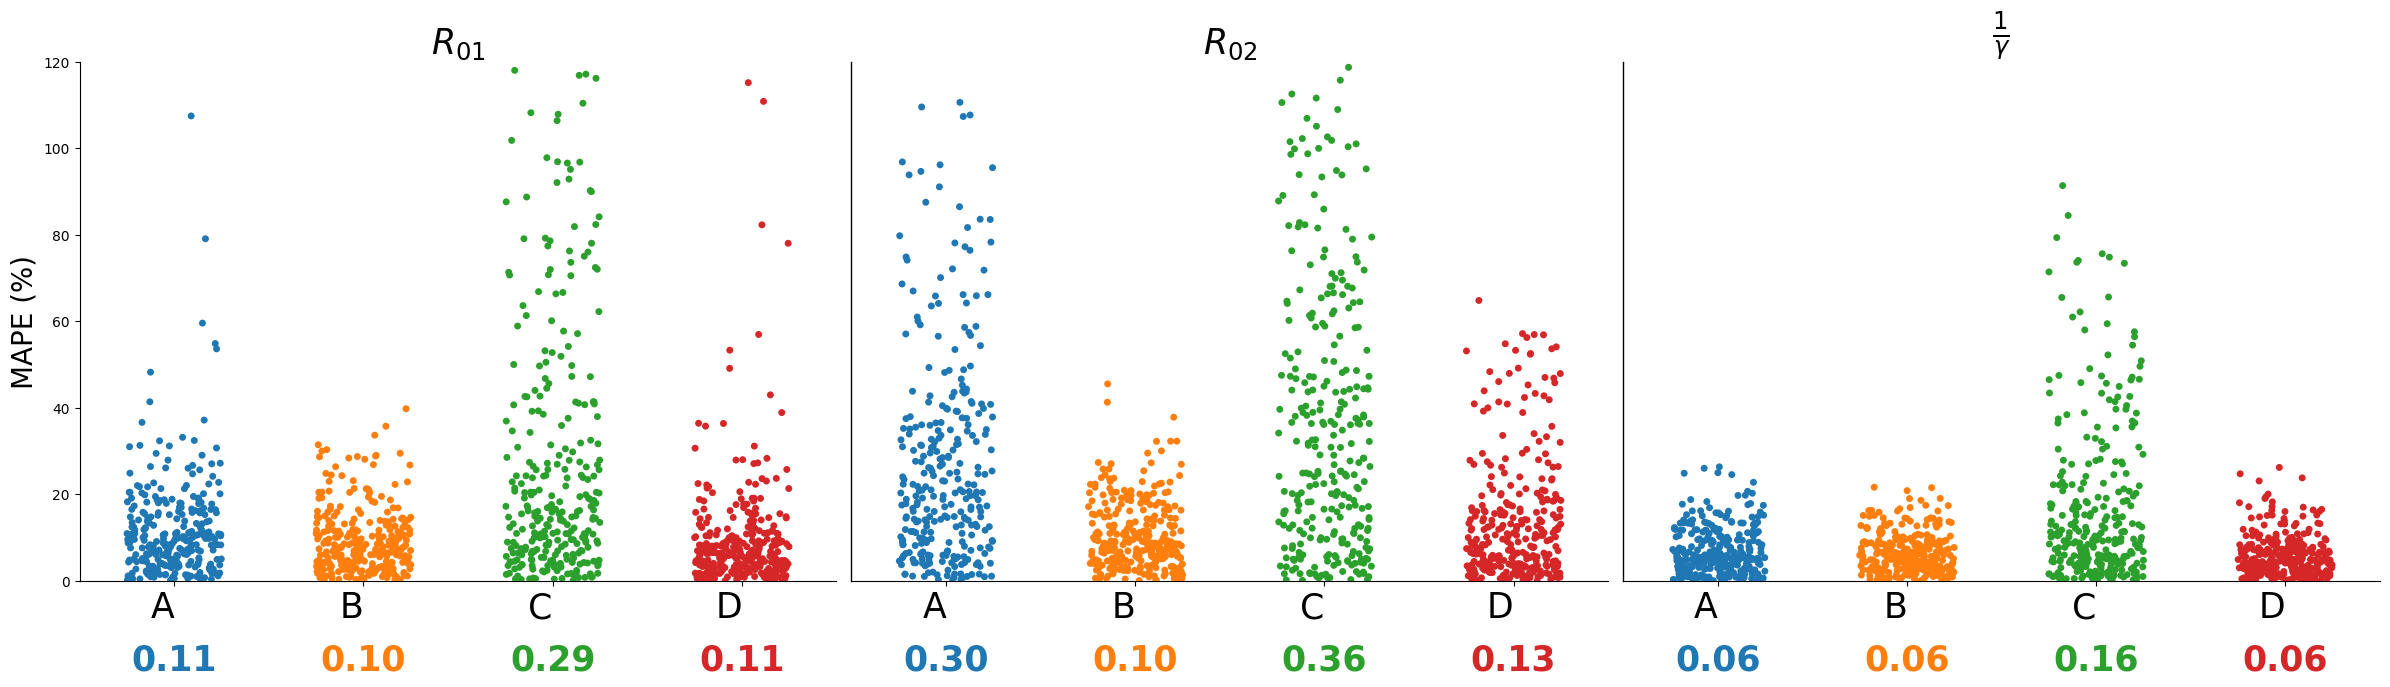

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# First 300 observations
# ---------------------------------------------------------

mape_cblv_only = MAPEs_cblv_only[:300]
mape_cblv_true = MAPEs_cblv_avec_true_mask[:300]
mape_cblv_pred = MAPEs_cblv_avec_pred_mask[:300]


# ---------------------------------------------------------
# Data
# ---------------------------------------------------------

data = [
    # R01
    [
        mape_cblv_only[:, 0],
        mape_cblv_true[:, 0],
        mape_cblv_pred[:, 0],
        mape_phylo["R_nought_1"][:300]
    ],

    # R02
    [
        mape_cblv_only[:, 1],
        mape_cblv_true[:, 1],
        mape_cblv_pred[:, 1],
        mape_phylo["R_nought_2"][:300]
    ],

    # Infectious period
    [
        mape_cblv_only[:, 2],
        mape_cblv_true[:, 2],
        mape_cblv_pred[:, 2],
        mape_phylo["infectious_period"][:300]
    ]
]

numbers = [
    [0.11, 0.10, 0.29, 0.11],  # R01
    [0.30, 0.10, 0.36, 0.13],  # R02
    [0.06, 0.06, 0.16, 0.06]   # 1/gamma
]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

colors = sns.color_palette(n_colors=4)

parameter_names = [r"$R_{01}$", r"$R_{02}$", r"$\frac{1}{\gamma}$"]

method_names = ["A","B","C","D"]


for i, (ax, parameter_data, parameter_name) in enumerate(
    zip(axes, data, parameter_names)
):

    sns.stripplot(data=parameter_data, jitter=0.25, size=5, palette=colors, ax=ax)

    ax.set_xticks(range(4))

    ax.set_xticklabels(method_names, rotation=0, ha="right", fontsize=25)

    ax.set_title(parameter_name,fontsize=25)

    ax.set_xlabel("")

    ax.set_ylim(0, 120)

    # Only the first plot has the y-axis
    if i == 0:
        ax.set_ylabel("MAPE (%)", fontsize=20)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Vertical separator between plots
    if i > 0:
        ax.spines["left"].set_visible(True)
        ax.spines["left"].set_linewidth(1)
        ax.spines["left"].set_color("black")


    # Mean MAPE below each column
    for x, number, color in zip(range(4), numbers[i], colors):

        mean_mape = np.mean(values)

        ax.text(x, -0.12, f"{number:.2f}", transform=ax.get_xaxis_transform(),
        ha="center", va="top", color=color, fontsize=25, fontweight="bold")


plt.tight_layout()

plt.savefig(
    r"C:\Users\JPC\Documents\MESTRADO\Projeto\gillespie-2\jitter_plots\mape_comparison.pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()